In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Shape of Dataset: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Display first five rows
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# print(X_scaled[:5])

In [6]:
# Empty list to store WCSS values
wcss = []


for k in range(2, 9):


    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

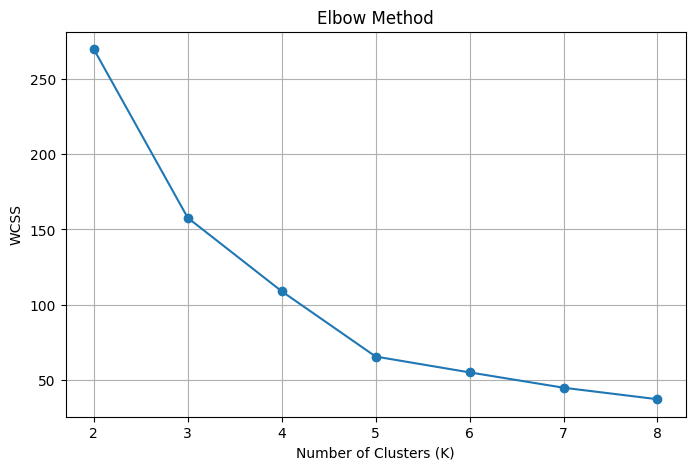

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(2,9), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

In [9]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


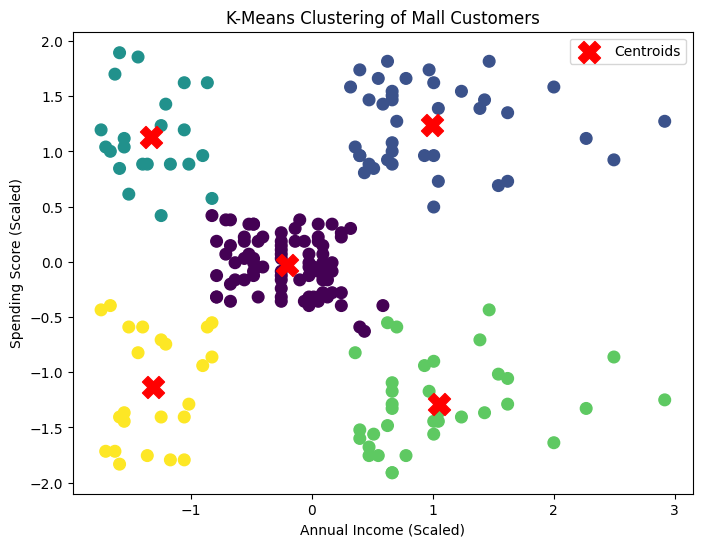

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis',
    s=70
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("K-Means Clustering of Mall Customers")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()

plt.show()

In [11]:
cluster_names = {
    0: "Low Income - Low Spending",
    1: "High Income - High Spending",
    2: "Average Income - Average Spending",
    3: "High Income - Low Spending",
    4: "Low Income - High Spending"
}

df["Business Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Business Segment
0,1,Male,19,15,39,4,Low Income - High Spending
1,2,Male,21,15,81,2,Average Income - Average Spending
2,3,Female,20,16,6,4,Low Income - High Spending
3,4,Female,23,16,77,2,Average Income - Average Spending
4,5,Female,31,17,40,4,Low Income - High Spending


In [12]:
summary = df.groupby("Business Segment")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

print(summary)

                                   Annual Income (k$)  Spending Score (1-100)
Business Segment                                                             
Average Income - Average Spending           25.727273               79.363636
High Income - High Spending                 86.538462               82.128205
High Income - Low Spending                  88.200000               17.114286
Low Income - High Spending                  26.304348               20.913043
Low Income - Low Spending                   55.296296               49.518519


In [13]:
print(df["Business Segment"].value_counts())

Business Segment
Low Income - Low Spending            81
High Income - High Spending          39
High Income - Low Spending           35
Low Income - High Spending           23
Average Income - Average Spending    22
Name: count, dtype: int64


In [14]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Business Segment
0,1,Male,19,15,39,4,Low Income - High Spending
1,2,Male,21,15,81,2,Average Income - Average Spending
2,3,Female,20,16,6,4,Low Income - High Spending
3,4,Female,23,16,77,2,Average Income - Average Spending
4,5,Female,31,17,40,4,Low Income - High Spending
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,High Income - High Spending
196,197,Female,45,126,28,3,High Income - Low Spending
197,198,Male,32,126,74,1,High Income - High Spending
198,199,Male,32,137,18,3,High Income - Low Spending
